In [1]:
!pip install yfinance

In [2]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import itertools
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm import tqdm
import yfinance as yf
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

In [4]:
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda")

In [5]:
data = yf.download("AAPL", start="2000-01-01", end="2026-04-01")
data = data[data.columns[:4]]
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2000-01-03,0.837002,0.841208,0.760359,0.784193
2000-01-04,0.766435,0.827188,0.756621,0.809430
2000-01-05,0.777650,0.826721,0.770173,0.775781
2000-01-06,0.710354,0.800083,0.710354,0.793540
2000-01-07,0.744002,0.755218,0.714093,0.721570


## Project question and data

This notebook explores whether daily AAPL price behavior can be modeled with three different time-series approaches: a Gaussian Hidden Markov Model (HMM), an LSTM, and ARIMA. The shared input is historical daily OHLC data (Open, High, Low, Close). The time-ordered split keeps earlier observations for training and later observations for testing, rather than randomly mixing future and past rows.

The key modeling choice is to predict a **relative intraday move** instead of the absolute closing-price level. For a day, the target feature is `(Close - Open) / Open`; this expresses the move as a fraction of that day's opening price. The high/open and open/low fractions provide additional intraday-range features. Relative targets are comparable across different price levels and focus learning on the movement rather than the long-term scale of the stock price.

# Gaussian HMM for stock price prediction

In [6]:
class StockHMM():
  def __init__(self, ticker = "AAPL", n_states=4, n_latency_days=10, test_size=0.2, n_step_change = 20, n_step_high = 10, n_step_low = 10):
    super(StockHMM).__init__()

    self.ticker = ticker
    self.n_latency_days = n_latency_days
    self.hmm = hmm.GaussianHMM(n_components=n_states)

    self.split_data(test_size)
    self.all_res(n_step_change, n_step_high, n_step_low)

  def split_data(self, test_size):
    data = yf.download(self.ticker, start="2000-01-01", end="2026-05-01")
    data = data[data.columns[:4]]
    train_data, test_data = train_test_split(data, test_size=test_size, shuffle=False)

    self.train_data = train_data
    self.test_data = test_data


  def extract_features(self, data):
    open_price = np.array(data['Open'])
    close_price = np.array(data['Close'])
    high_price = np.array(data['High'])
    low_price = np.array(data['Low'])


    frac_change = (close_price - open_price) / open_price
    frac_high = (high_price - open_price) / open_price
    frac_low = (open_price - low_price) / open_price

    return np.column_stack((frac_change, frac_high, frac_low))

  def fit(self):
    features = self.extract_features(self.train_data)
    self.hmm.fit(features)

  def all_res(self, n_step_change, n_step_high, n_step_low):
    change_range = np.linspace(-0.1,  0.1, n_step_change)
    high_range = np.linspace(0, 0.1, n_step_high)
    low_range = np.linspace(0, 0.1, n_step_low)

    self.all_outcomes = np.array(list(itertools.product(change_range, high_range, low_range)))

  def most_probable(self, day):
    prev_start = max(0, day - self.n_latency_days)
    prev_end = max(0, day - 1)
    prev_data = self.test_data.iloc[prev_start:prev_end]
    prev_features = self.extract_features(prev_data)

    score = []
    for outcome in self.all_outcomes:
      total = np.row_stack((prev_features, outcome))
      score.append(self.hmm.score(total))

    most = self.all_outcomes[np.argmax(score)]

    return most

  def predict_price(self, day):
    open_price = self.test_data.iloc[day]['Open']
    predicted_frac_change, _, _ = self.most_probable(day)
    return open_price * (1 + predicted_frac_change)

  def predict_for_days(self, start, end):
    predicted = []
    for day in tqdm(range(start, end)):
      predicted.append(self.predict_price(day))

    return predicted

  def plot_prediction(self, predicted, start, end):
    test_data = self.test_data[start:end]
    days = np.array(test_data.index, dtype="datetime64[ms]")
    actual = test_data['Close']
    fig = plt.figure(figsize=(12, 8))
    axes = fig.add_subplot(111)
    axes.plot(days, actual, 'bo-', label="actual")
    axes.plot(days, predicted, 'r+-', label="predicted")
    axes.set_title(f'{self.ticker}')

    fig.autofmt_xdate()

    plt.legend()
    plt.show()


[*********************100%***********************]  1 of 1 completed
100%|██████████| 100/100 [01:13<00:00,  1.37it/s]


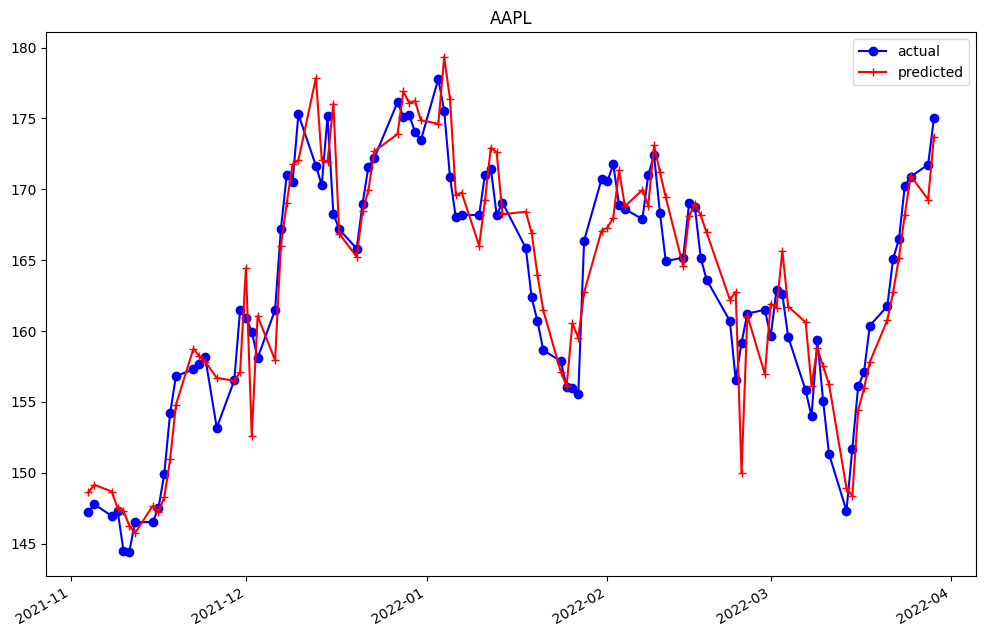

In [7]:
HMM_model = StockHMM()
HMM_model.fit()
hmm_predictions = HMM_model.predict_for_days(200, 300)
HMM_model.plot_prediction(hmm_predictions, 200, 300)

## Reading the HMM result

The HMM represents the feature sequence using four latent states. It does not directly emit a dollar price: the notebook searches a finite grid of candidate daily feature vectors, scores each candidate with the model's sequence log-likelihood, and converts the selected fractional close/open move back to a price using that day's Open.

The plot is a qualitative comparison for test-sample positions 200–299. The selected candidate is the highest-scoring option **within the chosen grid**; this is not a calibrated probability that the market will take that exact value. Read the figure as an exploratory forecast, not a trading signal.

# Model with LSTM layers

In [8]:
class StockLSTM(nn.Module):
  def __init__(self, input_dim=3, hidden_dim=64, output_dim=3, num_layers=2,
               ticker="AAPL", n_latency_days=10, test_size=0.2):
    super(StockLSTM, self).__init__()
    self.ticker = ticker
    self.n_latency_days = 10
    self.hidden_dim = hidden_dim
    self.num_layers = num_layers
    self.split_data(test_size)

    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    out, _ = self.lstm(x)
    return self.fc(out[:, -1, :])

  def split_data(self, test_size):
    data = yf.download(self.ticker, start="2000-01-01", end="2026-05-01")
    data = data[data.columns[:4]]

    train_data, test_data = train_test_split(data, test_size=test_size, shuffle=False)
    self.train_data = train_data
    self.test_data = test_data

  def extract_features(self, data):
    open_price = data['Open'].to_numpy().flatten()
    close_price = data['Close'].to_numpy().flatten()
    high_price = data['High'].to_numpy().flatten()
    low_price = data['Low'].to_numpy().flatten()

    frac_change = (close_price - open_price) / open_price
    frac_high = (high_price - open_price) / open_price
    frac_low = (open_price - low_price) / open_price

    return np.column_stack((frac_change, frac_high, frac_low))

  def create_sequences(self, features):
    X, y = [], []
    for i in range(len(features) - self.n_latency_days):
        X.append(features[i : i + self.n_latency_days])
        y.append(features[i + self.n_latency_days])
    return np.array(X), np.array(y)




In [9]:
def train(model, lr=0.001, epochs=20, batch_size=32):
  features = model.extract_features(model.train_data)
  X_train, y_train = model.create_sequences(features)

  X_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_tensor = torch.tensor(y_train, dtype=torch.float32)

  dataset = TensorDataset(X_tensor, y_tensor)
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  model.train()
  model.to(device)
  for epoch in range(epochs):
      epoch_loss = 0
      for batch_X, batch_y in loader:
          batch_X, batch_y = batch_X.to(device), batch_y.to(device)

          optimizer.zero_grad()
          predictions = model(batch_X)
          loss = criterion(predictions, batch_y)
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()

      print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader):.6f}")

In [10]:
def predict_price(model, day):
  if day < model.n_latency_days:
      history_needed = model.n_latency_days - day
      train_tail = model.train_data.iloc[-history_needed:]
      test_head = model.test_data.iloc[0:day]
      combined_data = pd.concat([train_tail, test_head]) if day > 0 else train_tail
  else:
      combined_data = model.test_data.iloc[day - model.n_latency_days : day]

  prev_features = model.extract_features(combined_data)

  input_tensor = torch.tensor(prev_features, dtype=torch.float32).unsqueeze(0).to(device)

  model.eval()
  with torch.no_grad():
      predicted_features = model(input_tensor).cpu().numpy()[0]

  predicted_frac_change = predicted_features[0]

  open_price = model.test_data.iloc[day]['Open']
  if isinstance(open_price, torch.Tensor) or hasattr(open_price, 'values'):
      open_price = open_price.item()

  return open_price * (1 + predicted_frac_change)

In [11]:
def predict_for_days(model, start, end):
  predicted = []
  for day in tqdm(range(start, end)):
      predicted.append(predict_price(model, day))

  return predicted

def plot_predict(model, predicted, start, end):
  test_data = model.test_data.iloc[start:end]
  dates = np.array(test_data.index, dtype="datetime64[ms]")
  actual = test_data['Close'].to_numpy().flatten()

  fig = plt.figure(figsize=(12, 8))
  axes = fig.add_subplot(111)
  axes.plot(dates, actual, 'bo-', label="actual")
  axes.plot(dates, predicted, 'r+-', label="predicted")
  axes.set_title(f'{model.ticker} (LSTM)')

  fig.autofmt_xdate()
  plt.legend()
  plt.show()

[*********************100%***********************]  1 of 1 completed


Epoch 1/20, Loss: 0.000623
Epoch 2/20, Loss: 0.000304
Epoch 3/20, Loss: 0.000296
Epoch 4/20, Loss: 0.000285
Epoch 5/20, Loss: 0.000277
Epoch 6/20, Loss: 0.000275
Epoch 7/20, Loss: 0.000275
Epoch 8/20, Loss: 0.000275
Epoch 9/20, Loss: 0.000275
Epoch 10/20, Loss: 0.000274
Epoch 11/20, Loss: 0.000273
Epoch 12/20, Loss: 0.000277
Epoch 13/20, Loss: 0.000271
Epoch 14/20, Loss: 0.000272
Epoch 15/20, Loss: 0.000272
Epoch 16/20, Loss: 0.000272
Epoch 17/20, Loss: 0.000269
Epoch 18/20, Loss: 0.000272
Epoch 19/20, Loss: 0.000273
Epoch 20/20, Loss: 0.000273


100%|██████████| 100/100 [00:00<00:00, 401.46it/s]


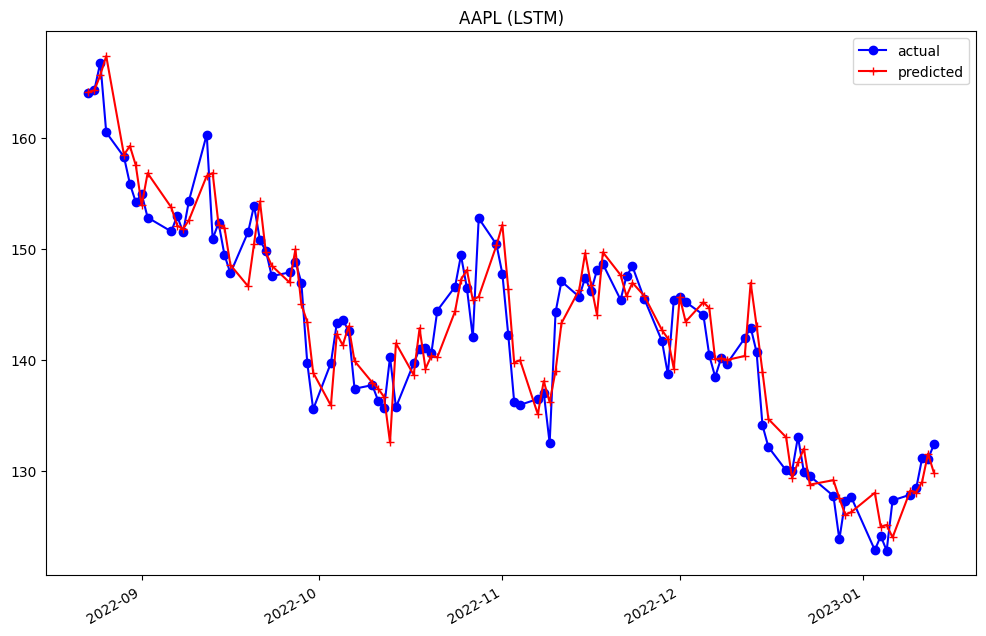

In [12]:
LSTM_model = StockLSTM()
train(LSTM_model)
LSTM_model.to(device)
lstm_predictions = predict_for_days(LSTM_model, 400, 500)
plot_predict(LSTM_model, lstm_predictions, 400, 500)

## Reading the feature-based LSTM result

This LSTM receives a sequence of the previous 10 days of three relative OHLC features and learns to predict the next feature vector. The closing-price estimate is reconstructed from the predicted fractional move and the known opening price: `predicted Close = Open × (1 + predicted fractional change)`.

The plot uses test-sample positions 400–499. It shows whether a neural sequence model can map recent intraday behavior to a next-day relative move. This is a separate test window from the HMM plot, so the two figures are not a strict same-days model comparison.

[*********************100%***********************]  1 of 1 completed


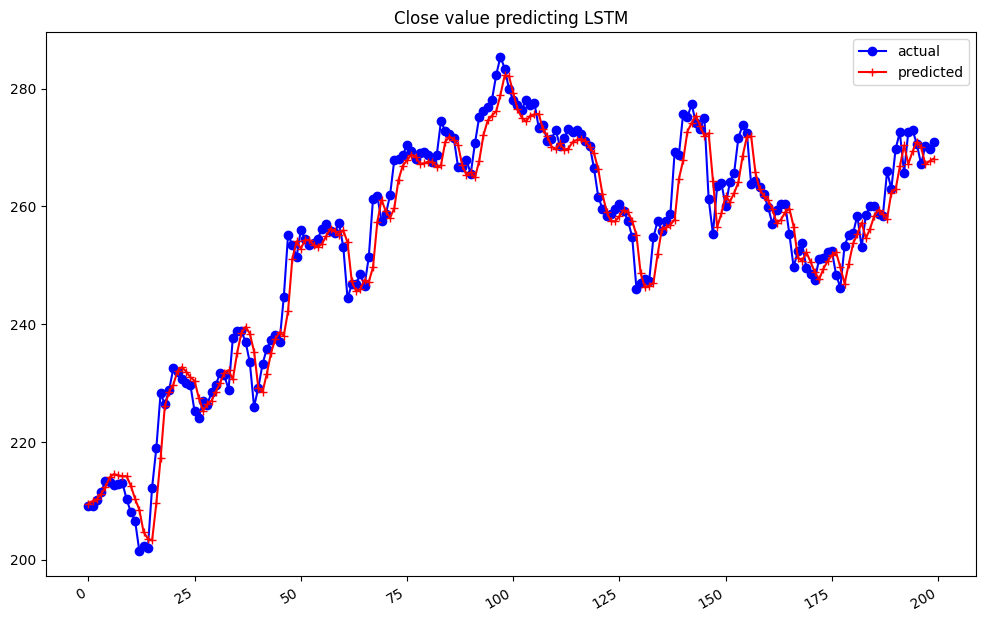

In [13]:
import torch
import torch.nn as nn
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

data = yf.download("AAPL", start="2000-01-01", end="2026-05-01")['Close'].to_numpy().flatten()

min_val, max_val = data.min(), data.max()
scaled_data = (data - min_val) / (max_val - min_val)

X, y = [], []
for i in range(len(scaled_data) - 10):
    X.append(scaled_data[i : i + 10])
    y.append(scaled_data[i + 10])

X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)

split = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


class ShortLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ShortLSTM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model.train()
model.to(device)
for epoch in range(100):
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()


model.eval()
with torch.no_grad():
    predicted_scaled = model(X_test.to(device)).cpu().numpy()

predicted = predicted_scaled * (max_val - min_val) + min_val
actual = y_test.numpy() * (max_val - min_val) + min_val

fig = plt.figure(figsize=(12, 8))
axes = fig.add_subplot(111)
axes.plot(actual[-200:], 'bo-', label="actual")
axes.plot(predicted[-200:], 'r+-', label="predicted")
axes.set_title('Close value predicting LSTM')

fig.autofmt_xdate()
plt.legend()
plt.show()

## Contrast: predicting the absolute Close level

This experiment trains a second, simpler LSTM on the Close series itself: ten scaled closing prices are used to predict the next scaled close. It is included to motivate the target design. Price levels are strongly dominated by the stock's changing long-term scale; a model can visually track a smooth level or trend while still missing the day-to-day movement of interest. Predicting relative changes instead centers the task on those movements.

**Interpret this plot cautiously:** in the current code, the `actual` series is multiplied by `(max_val - min_val)` but does not add `min_val` back, while the predictions do add it. Also, the min/max scaling is computed before the train/test split, so the test period influences preprocessing. These details can distort the displayed comparison; the plot is a useful motivation for the experiment, but not conclusive evidence against absolute-price forecasting.

# ARIMA Model Implementation

## Why ARIMA, and what the stationarity checks say

The notebook first inspects the Close series and its first difference using ACF/PACF plots, then applies the Augmented Dickey–Fuller test to the differenced series. The recorded p-value is approximately `7.97 × 10⁻²⁸`, strong evidence against a unit root in that differenced series under the test assumptions. This supports modeling a differenced/relative series rather than assuming the raw price level is stationary.

The ARIMA baseline forecasts the same kind of intraday fractional change, `(Close - Open) / Open`, and converts the forecast back to a Close using the known Open. It uses order `(2, 1, 2)` and performs a walk-forward evaluation: after each one-step forecast, the observed test-period change is added to the history before the next forecast.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

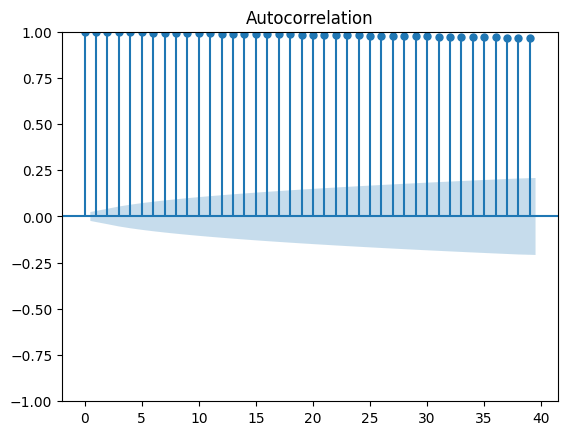

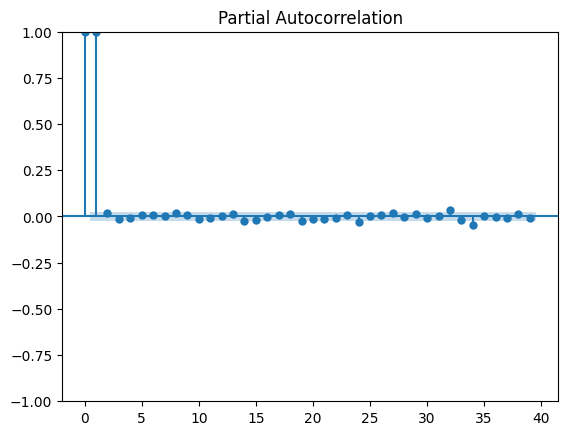

In [ ]:
data = pd.DataFrame(data)

data_acf = plot_acf(data['Close'])
data_pacf = plot_pacf(data['Close'])

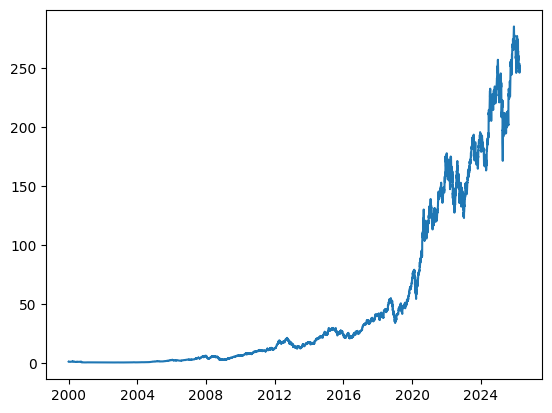

In [ ]:
plt.plot(data["Close"])

<Axes: xlabel='Date'>

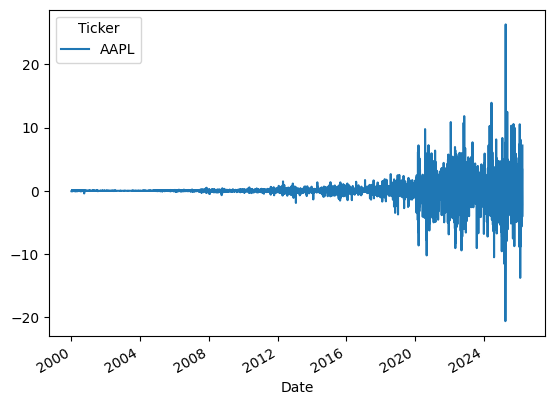

In [ ]:
first_diff = data.diff().dropna()
first_diff["Close"].plot()

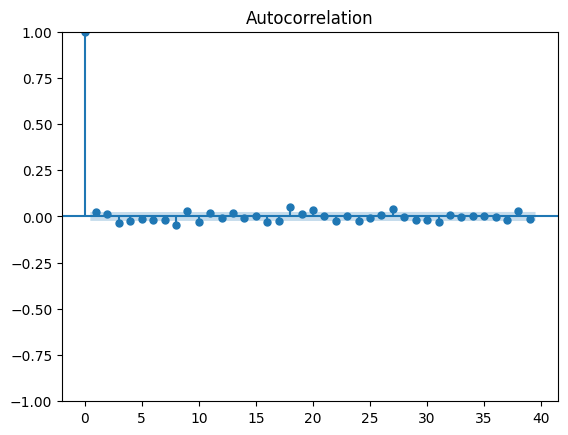

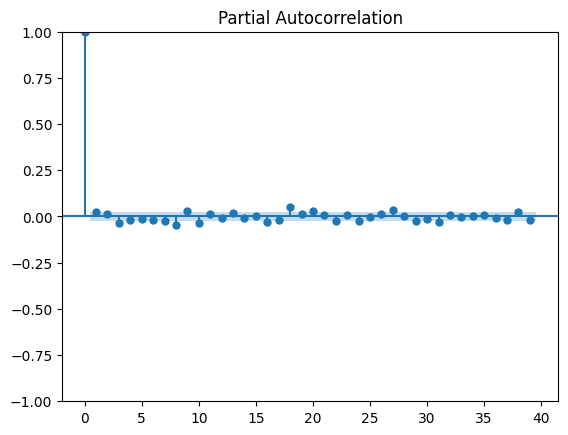

In [ ]:
acf_diff = plot_acf(first_diff["Close"])
pacf_diff = plot_pacf(first_diff["Close"])

In [ ]:
adfuller(first_diff["Close"])[1]

np.float64(7.966976851818795e-28)

[*********************100%***********************]  1 of 1 completed
100%|██████████| 100/100 [08:30<00:00,  5.10s/it]


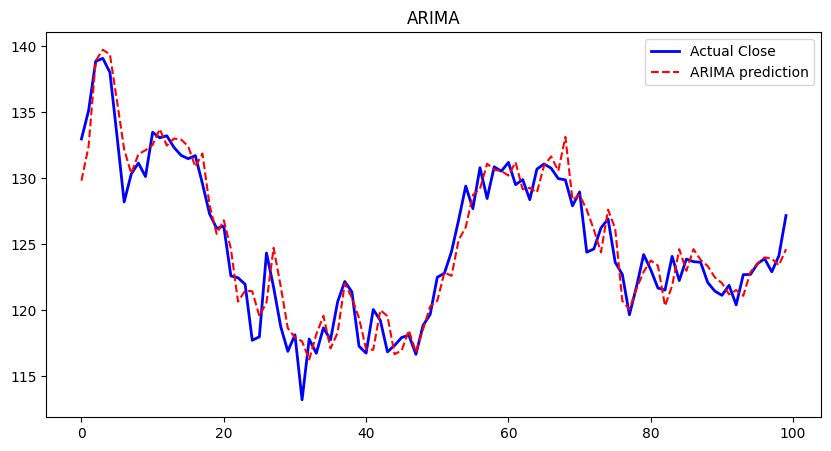

In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm

df = yf.download("AAPL", start="2000-01-01", end="2026-05-01")
open_prices = df['Open'].to_numpy().flatten()
close_prices = df['Close'].to_numpy().flatten()

frac_change = (close_prices - open_prices) / open_prices

split = int(len(frac_change) * 0.8)
history = list(frac_change[:split])
test_frac = frac_change[split:]
test_open = open_prices[split:]
test_close = close_prices[split:]

days_to_predict = 100
predicted_close = []

for t in tqdm(range(days_to_predict)):
    model = ARIMA(history, order=(2, 1, 2))
    model_fit = model.fit()

    pred_frac = model_fit.forecast()[0]

    pred_close = test_open[t] * (1 + pred_frac)
    predicted_close.append(pred_close)

    history.append(test_frac[t])

plt.figure(figsize=(10, 5))
plt.plot(test_close[:days_to_predict], label="Actual Close", color="blue", lw=2)
plt.plot(predicted_close, label="ARIMA prediction", color="red", linestyle="--")
plt.title("ARIMA")
plt.legend()
plt.show()

## Interpreting the ARIMA plot and comparing approaches

The ARIMA figure compares actual and forecast Close values for the first 100 test observations. Its predictions come from forecasts of fractional intraday change, not from modeling the dollar Close directly.

These figures are exploratory rather than a controlled leaderboard: HMM is plotted on test positions 200–299, the feature LSTM on 400–499, and ARIMA on the first 100 test observations. The notebook does not currently report common-window MAE/RMSE or directional accuracy, so it does not establish which model performs best. It also does not test a trading strategy or account for transaction costs. The main result is the modeling comparison and the motivation for using a scale-relative target—not evidence of profitable stock prediction.